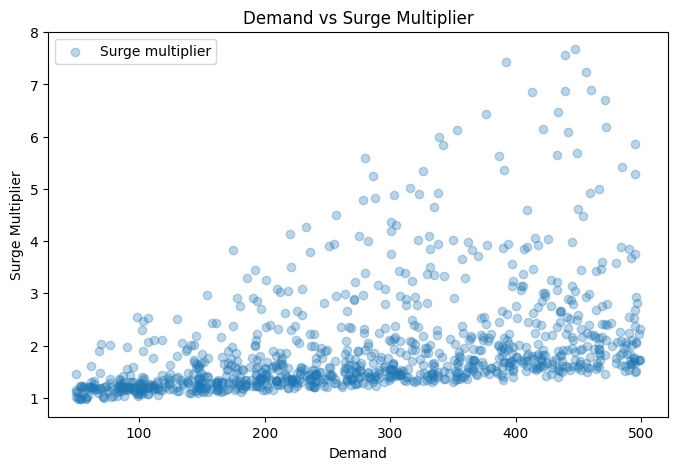

RMSE on test set: 0.1028


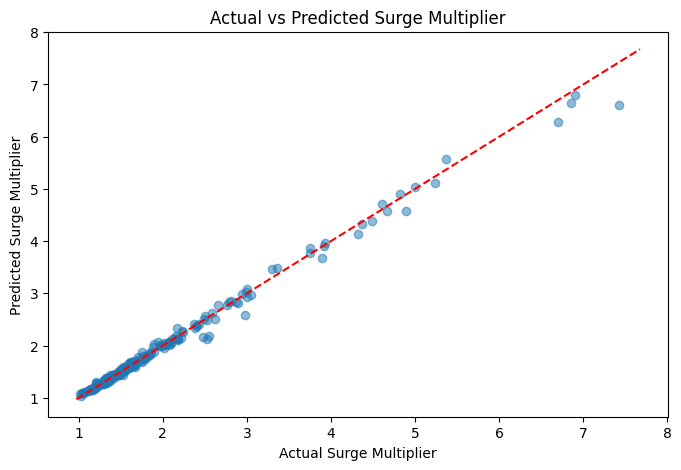

Predicted surge multiplier for example: 2.3607702643305943


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Generate simulated data
np.random.seed(42)
data = pd.DataFrame({
    'demand': np.random.randint(50, 500, 1000),
    'supply': np.random.randint(30, 450, 1000),
    'time_of_day': np.random.randint(0, 24, 1000),
})
data['surge_multiplier'] = 1 + (data['demand'] / (data['supply'] + 1)) * 0.5 + 0.1 * np.sin(data['time_of_day'] / 24 * 2 * np.pi)

# Plot demand vs surge multiplier to visualize relationship
plt.figure(figsize=(8,5))
plt.scatter(data['demand'], data['surge_multiplier'], alpha=0.3, label='Surge multiplier')
plt.xlabel('Demand')
plt.ylabel('Surge Multiplier')
plt.title('Demand vs Surge Multiplier')
plt.legend()
plt.show()

# Prepare data for modeling
X = data[['demand', 'supply', 'time_of_day']]
y = data['surge_multiplier']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE on test set: {rmse:.4f}')

# Visualize predicted vs actual surge multiplier
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Surge Multiplier')
plt.ylabel('Predicted Surge Multiplier')
plt.title('Actual vs Predicted Surge Multiplier')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # line y=x for reference
plt.show()

# Example prediction
example = pd.DataFrame({'demand': [300], 'supply': [100], 'time_of_day': [18]})
print("Predicted surge multiplier for example:", model.predict(example)[0])


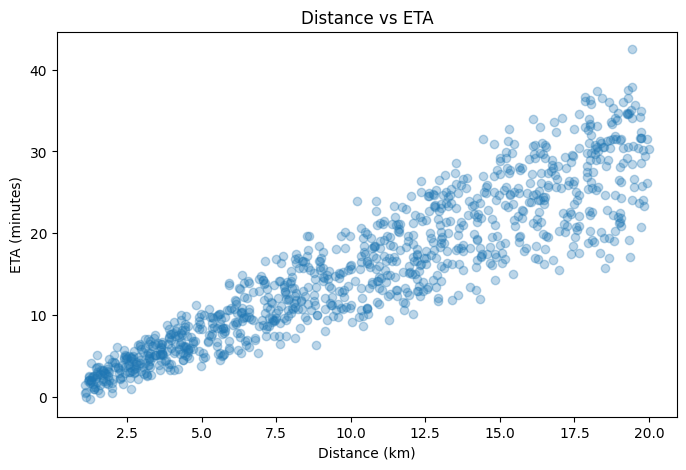

RMSE on ETA prediction: 1.1502


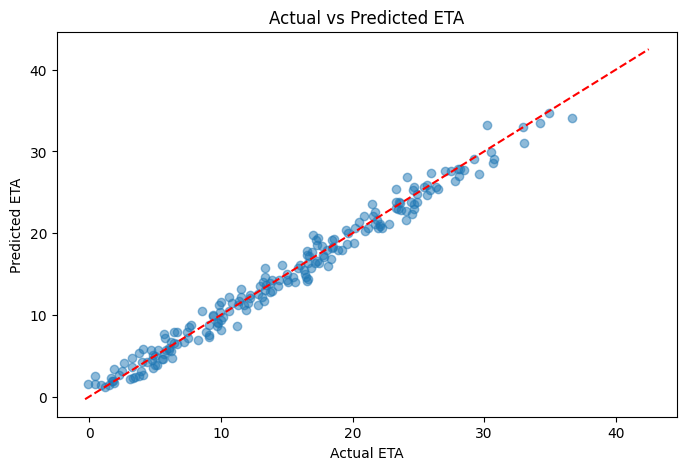

Predicted ETA for example: 15.683724887965631


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

np.random.seed(42)
data = pd.DataFrame({
    'distance': np.random.uniform(1, 20, 1000),
    'traffic_level': np.random.uniform(0, 1, 1000),
    'time_of_day': np.random.randint(0, 24, 1000)
})
data['eta'] = data['distance'] * (1 + data['traffic_level']) * (1 + 0.1*np.sin(data['time_of_day']/24*2*np.pi)) + np.random.normal(0, 1, 1000)

# Visualize distance vs ETA
plt.figure(figsize=(8,5))
plt.scatter(data['distance'], data['eta'], alpha=0.3)
plt.xlabel('Distance (km)')
plt.ylabel('ETA (minutes)')
plt.title('Distance vs ETA')
plt.show()

# Prepare dataset
X = data[['distance', 'traffic_level', 'time_of_day']]
y = data['eta']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE on ETA prediction: {rmse:.4f}')

# Plot Actual vs Predicted ETA
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual ETA')
plt.ylabel('Predicted ETA')
plt.title('Actual vs Predicted ETA')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# Example prediction
example = pd.DataFrame({'distance': [10], 'traffic_level': [0.7], 'time_of_day': [17]})
print("Predicted ETA for example:", model.predict(example)[0])


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Simulated normal data
np.random.seed(42)
data = pd.DataFrame({
    'number_of_rides': np.random.randint(1, 50, 1000),
    'average_ride_distance': np.random.uniform(0.5, 15, 1000),
    'avg_payment_amount': np.random.uniform(5, 100, 1000),
})

# Add fraudulent examples
fraud = pd.DataFrame({
    'number_of_rides': [200, 180],
    'average_ride_distance': [0.1, 30],
    'avg_payment_amount': [5000, 0.1],
})

data = pd.concat([data, fraud], ignore_index=True)

model = IsolationForest(contamination=0.002, random_state=42)
model.fit(data)

data['anomaly_score'] = model.decision_function(data)
data['fraud_pred'] = model.predict(data)  # -1 = anomaly, 1 = normal

# Visualize anomaly scores
plt.figure(figsize=(10,5))
plt.scatter(data.index, data['anomaly_score'], c=data['fraud_pred'], cmap='coolwarm', label='Anomaly Score')
plt.colorbar(label='Anomaly Prediction (-1=fraud, 1=normal)')
plt.xlabel('Sample Index')
plt.ylabel('Anomaly Score')
plt.title('Fraud Detection Anomaly Scores')
plt.show()

# Show detected fraud samples
print("Detected fraud samples:")
print(data[data['fraud_pred'] == -1])


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- anomaly_score


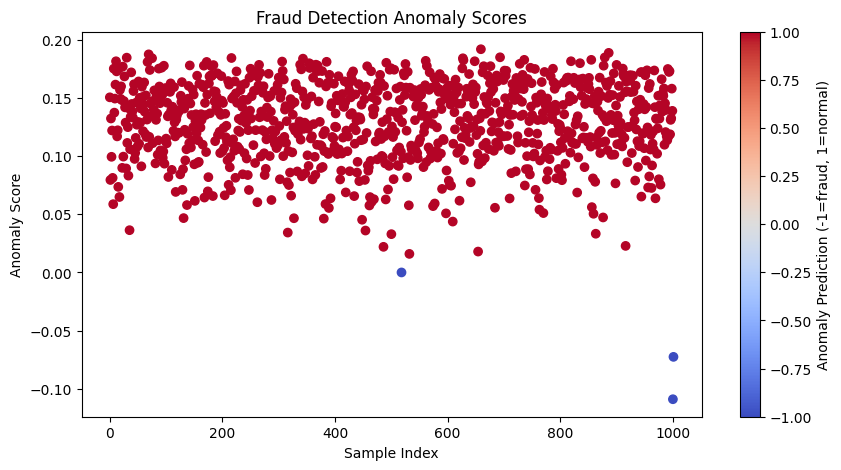

Detected fraud samples:
      number_of_rides  average_ride_distance  avg_payment_amount  \
518                49               1.339847            5.017898   
1000              200               0.100000         5000.000000   
1001              180              30.000000            0.100000   

      anomaly_score  fraud_pred  
518       -0.000032          -1  
1000      -0.108982          -1  
1001      -0.072579          -1  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Simulated normal data
np.random.seed(42)
data = pd.DataFrame({
    'number_of_rides': np.random.randint(1, 50, 1000),
    'average_ride_distance': np.random.uniform(0.5, 15, 1000),
    'avg_payment_amount': np.random.uniform(5, 100, 1000),
})

# Add fraudulent examples
fraud = pd.DataFrame({
    'number_of_rides': [200, 180],
    'average_ride_distance': [0.1, 30],
    'avg_payment_amount': [5000, 0.1],
})

data = pd.concat([data, fraud], ignore_index=True)

model = IsolationForest(contamination=0.002, random_state=42)
model.fit(data)

# Calculate anomaly scores
data['anomaly_score'] = model.decision_function(data)

# Predict fraud status using only the original features the model was trained on
# Do not include the 'anomaly_score' column when predicting
original_features = ['number_of_rides', 'average_ride_distance', 'avg_payment_amount']
data['fraud_pred'] = model.predict(data[original_features])  # -1 = anomaly, 1 = normal


# Visualize anomaly scores
plt.figure(figsize=(10,5))
# Use the anomaly score for color, and the prediction for filtering/labeling if needed
scatter = plt.scatter(data.index, data['anomaly_score'], c=data['fraud_pred'], cmap='coolwarm', label='Anomaly Score')
plt.colorbar(scatter, label='Anomaly Prediction (-1=fraud, 1=normal)')
plt.xlabel('Sample Index')
plt.ylabel('Anomaly Score')
plt.title('Fraud Detection Anomaly Scores')
plt.show()

# Show detected fraud samples
print("Detected fraud samples:")
print(data[data['fraud_pred'] == -1])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grid setup
n_states = 16
goal = 15
obstacles = [5,7,11,12]
actions = [0,1,2,3]  # up, right, down, left

Q = np.zeros((n_states, len(actions)))
alpha = 0.8
gamma = 0.95
epsilon = 0.1

def step(state, action):
    row, col = divmod(state, 4)
    if action == 0: row -= 1
    elif action == 1: col += 1
    elif action == 2: row += 1
    elif action == 3: col -= 1
    if row < 0 or row > 3 or col < 0 or col > 3:
        return state, -1, False
    next_state = row*4 + col
    if next_state in obstacles:
        return state, -5, False
    if next_state == goal:
        return next_state, 10, True
    return next_state, -0.1, False

# Train Q-learning
for ep in range(1000):
    state = 0
    done = False
    while not done:
        if np.random.rand() < epsilon:
            action = np.random.choice(actions)
        else:
            action = np.argmax(Q[state])
        next_state, reward, done = step(state, action)
        Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])
        state = next_state

# Visualize best policy arrows on grid
policy = np.argmax(Q, axis=1)
action_symbols = ['↑', '→', '↓', '←']

grid_display = []
for s in range(n_states):
    if s in obstacles:
        grid_display.append('X')
    elif s == goal:
        grid_display.append('G')
    else:
        grid_display.append(action_symbols[policy[s]])

print("Policy grid (X=obstacle, G=goal):")
for i in range(4):
    print(grid_display[i*4:(i+1)*4])


Policy grid (X=obstacle, G=goal):
['→', '→', '↓', '←']
['↓', 'X', '↓', 'X']
['→', '→', '↓', 'X']
['X', '→', '→', 'G']
